In [27]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from numpy.random import Generator, PCG64
from qiskit_aer import AerSimulator
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2 as Estimator

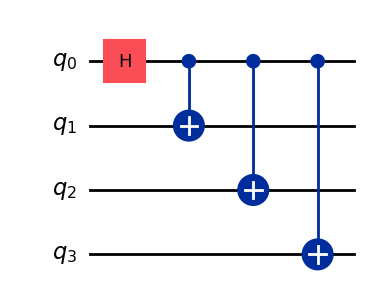

In [28]:
# Create a new circuit with two qubits
qc = QuantumCircuit(4)

# Add a Hadamard gate to qubit 0
qc.h(0)

# Perform a controlled-X gate on qubit 1, controlled by qubit 0
qc.cx(0, 1)
qc.cx(0, 2)
qc.cx(0, 3)

# Return a drawing of the circuit using MatPlotLib ("mpl").
# These guides are written by using Jupyter notebooks, which
# display the output of the last line of each cell.
# If you're running this in a script, use `print(qc.draw())` to
# print a text drawing.
qc.draw("mpl")

In [29]:
# Set up six different observables.


observables = [SparsePauliOp("ZIZZ")]

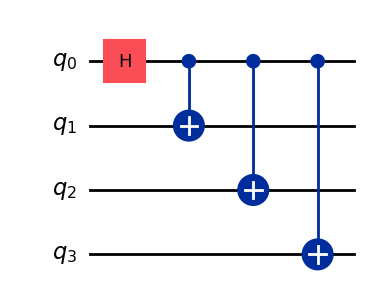

In [30]:
backend = AerSimulator(method="statevector")

# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
isa_circuit.draw("mpl")

In [38]:
from qiskit_ibm_runtime.options.utils import UnsetType
from qiskit_ibm_runtime import EstimatorOptions

# Run:
mapped_observables = [
    observable.apply_layout(isa_circuit.layout) for observable in observables
]
my_options = EstimatorOptions()
# Turn off all error mitigation and suppression
# my_options.resilience_level = 0
# my_options.default_shots = 420
my_options.default_precision = 0.1
# my_options.seed_estimator = 42
# my_options.simulator.seed_simulator = 42
# print(my_options)
# my_options.options.environment.log_level = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_LEVEL = "DEBUG"
# QISKIT_IBM_RUNTIME_LOG_FILE = "LOGGER.txt"
estimator = Estimator(backend, options=my_options)

from qiskit.primitives import StatevectorEstimator
if isinstance(my_options.default_precision, UnsetType):
    precision = 0.0
else:
    precision = my_options.default_precision
# if isinstance(my_options.simulator.seed_simulator, UnsetType):
#     seed = None
# else:
#     seed = my_options.simulator.seed_simulator
seed = 42
seed = Generator(PCG64(seed))
estimator = StatevectorEstimator(default_precision=precision, seed=seed)
# mapped_observables = observables
# isa_circuit = qc

values = []
for _ in range(1000):
    pubs = [(isa_circuit, mapped_observables)]


    job = estimator.run(pubs)

    for pub_result in job.result():
        values.append(pub_result.data.evs[0])
print(values)

[np.float64(0.030471707975443137), np.float64(-0.10399841062404956), np.float64(0.07504511958064573), np.float64(0.0940564716391214), np.float64(-0.19510351886538366), np.float64(-0.13021795068623182), np.float64(0.012784040316728537), np.float64(-0.03162425923435822), np.float64(-0.0016801157504288797), np.float64(-0.08530439275735802), np.float64(0.08793979748628286), np.float64(0.07777919354289484), np.float64(0.006603069756121605), np.float64(0.11272412069680329), np.float64(0.046750934225204564), np.float64(-0.08592924628832382), np.float64(0.036875078408249884), np.float64(-0.0958882600828999), np.float64(0.08784503013072725), np.float64(-0.00499259109862529), np.float64(-0.018486236354526057), np.float64(-0.06809295444039414), np.float64(0.12225413386740303), np.float64(-0.015452948206880215), np.float64(-0.042832782216310726), np.float64(-0.03521335504882296), np.float64(0.05323091855533488), np.float64(0.036544406436407835), np.float64(0.04127326115959884), np.float64(0.043082

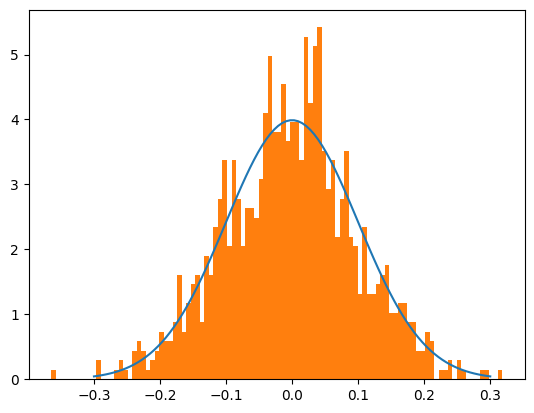

In [39]:
# This is the result from our single pub, which had six observables,
# so contains information on all six.
import scipy.stats as stats


mu = 0
variance = my_options.default_precision**2
sigma = np.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma))
plt.hist(values, density=True, bins=100)
plt.show()

These discrete peaks are due to the following effect:
- The only physically possible measurements are -1 and +1.
- For a given precision $p$ the estimator takes $\sim \frac{1}{p^2}$ shots from -1 and +1.
- The values can only combine to discrete values for a small amount of shots.

In [34]:
old_values = np.array(values.copy())

In [40]:
for a,b in zip(values, old_values):
    print(a-b)

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
